## Modeling — One Honest Baseline

I understand the data and have a lean 42-feature set. The question now is whether a single
gradient-boosted model can reliably predict RUL **at the decision point** — the last observed
cycle of each engine, which is the only cycle that matters operationally.

Get the evaluation right first, then the model.

In [ ]:
import shutil, sys, warnings
from pathlib import Path

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from turbofan.features.engineering import add_features
from turbofan.evaluation.protocol import eval_lc
from turbofan.data.loader import load_dataset
from turbofan.models.xgboost_model import XGBoostRUL
from turbofan.evaluation.metrics import (
    cmapss_score, late_prediction_pct, per_bucket_metrics, rmse
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

RAW     = Path('../data/raw')
MODELS  = Path('../models')
MODELS.mkdir(exist_ok=True)
RUL_CAP = 125
XGB_DEV = 'cuda' if shutil.which('nvidia-smi') is not None else 'cpu'

KEEP      = ['s2','s3','s4','s7','s8','s9','s11','s12','s13','s14','s15','s17','s20','s21']
FEAT_COLS = ([f'{s}_n'     for s in KEEP] +
             [f'{s}_mean'  for s in KEEP] +
             [f'{s}_slope' for s in KEEP])

print(f'XGBoost device : {XGB_DEV}')
print(f'Feature count  : {len(FEAT_COLS)}')

In [ ]:
def make_val_instances(feat_df, step=5):
    # Sample a truncation instance at every step-th cycle from each val engine's
    # degradation phase (RUL < 125). Covers the full RUL range, matching the
    # test-set distribution. Skips the healthy plateau where RUL is capped.
    parts = []
    for unit, grp in feat_df.groupby('unit'):
        degrade = grp[grp['rul'] < RUL_CAP].sort_values('cycle')
        if len(degrade) == 0:
            degrade = grp.sort_values('cycle')
        parts.append(degrade.iloc[::step])
    return pd.concat(parts, ignore_index=True)


def eval_instances(model, inst_df):
    # Evaluate on a set of truncation instances (each row = one prediction task).
    X    = inst_df[FEAT_COLS]
    y    = inst_df['rul'].values.astype(float)
    pred = model.predict(X)
    out  = {'rmse':         rmse(y, pred),
            'cmapss_score': cmapss_score(y, pred),
            'late_pct':     late_prediction_pct(y, pred),
            'n_engines':    len(y)}
    out.update(per_bucket_metrics(y, pred))
    return out, y, pred


def tune(feat_tr_df, val_inst_df, n_trials=20, seed=42):
    # Optimise on val-instance RMSE covering the full RUL range.
    X_tr = feat_tr_df[FEAT_COLS];  y_tr = feat_tr_df['rul'].values
    X_va = val_inst_df[FEAT_COLS]; y_va = val_inst_df['rul'].values

    def obj(trial):
        p = dict(
            n_estimators     = 1000,
            max_depth        = trial.suggest_int('max_depth', 3, 8),
            learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            subsample        = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 1.0),
            reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 5.0),
            tree_method='hist', device=XGB_DEV, random_state=seed,
        )
        m = XGBoostRUL(params=p)
        m.fit(X_tr, y_tr, X_va, y_va, verbose=False)
        return eval_instances(m, val_inst_df)[0]['rmse']

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=True)
    return study

## Evaluation protocol — why it matters

The C-MAPSS test set is **not** run-to-failure. Each test engine is truncated at an
arbitrary point in its life; NASA provides the true remaining life in `RUL_FD00x.txt`.
The task is: given the engine's history up to that truncation, predict the RUL at that
moment.

**All-rows RMSE is the wrong metric.** An engine with 300 training cycles spends most
of its life in the healthy plateau (RUL capped at 125). Evaluating over all those rows
means grading mostly on the easy region — predicting ~125 when the engine is healthy is
trivially accurate. That's not the hard problem.

**The right protocol:** for each engine (val or test), predict once at a truncation
point and compare to the true RUL.

**Validation via truncation instances:** instead of evaluating only at the last cycle
(which always has RUL=0 for run-to-failure training engines), `make_val_instances`
samples every 5th cycle from each val engine's degradation phase (RUL < 125). This
gives ~5–20 instances per engine covering the full 0–125 RUL range. Optuna minimises
val-instance RMSE, so the tuned model is calibrated across the entire range, not just
tuned to predict near-failure.

**Test evaluation:** one prediction per engine at its NASA-defined truncation point,
compared to the ground-truth RUL file. `eval_lc` handles this.

Val and test now measure the same thing — single-point prediction at a truncation —
and their numbers are directly comparable.

In [ ]:
datasets = {}
for name in ('FD001', 'FD002', 'FD003', 'FD004'):
    datasets[name] = load_dataset(name, RAW)
    tr, te, rul_te = datasets[name]
    print(f"{name}: {tr['unit'].nunique():3d} train engines, {te['unit'].nunique():3d} test engines")

## One model, FD001 first

FD001 is the simplest case — one operating condition, one fault mode. It's the right
dataset to prove the eval protocol is wired up correctly before scaling to FD002/FD004.
I'll do a 20-trial Optuna search optimising on val-instance RMSE across the full RUL
range, then evaluate on the real test set.

In [4]:
tr1, te1, rul_te1 = datasets['FD001']

engines    = tr1['unit'].unique()
split      = int(len(engines) * 0.8)
tr_e, va_e = engines[:split], engines[split:]

feat_tr1, stats1 = add_features(tr1[tr1['unit'].isin(tr_e)], KEEP, 'FD001')
feat_va1, _      = add_features(tr1[tr1['unit'].isin(va_e)], KEEP, 'FD001', stats=stats1)
val_inst1        = make_val_instances(feat_va1)

print(f'Train: {len(tr_e)} engines  |  Val: {len(va_e)} engines, '
      f'{len(val_inst1)} truncation instances')
print('Running Optuna (20 trials, val-instance RMSE across full RUL range)...')
study1 = tune(feat_tr1, val_inst1, n_trials=20)

best1 = {**study1.best_params, 'n_estimators': 1000, 'tree_method': 'hist',
         'device': XGB_DEV, 'random_state': 42}
model1 = XGBoostRUL(params=best1)
model1.fit(feat_tr1[FEAT_COLS], feat_tr1['rul'].values,
           val_inst1[FEAT_COLS], val_inst1['rul'].values, verbose=False)

model1.save(MODELS / 'xgboost_FD001.pkl')
joblib.dump(stats1, MODELS / 'features_FD001.joblib')

print(f'Best val-instance RMSE : {study1.best_value:.2f} cycles')
print(f'Stopped at iteration   : {model1.best_iteration_}')
print(f'Best params: {study1.best_params}')

Train: 80 engines  |  Val: 20 engines, 500 truncation instances
Running Optuna (20 trials, val-instance RMSE across full RUL range)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: 17.3931:   0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: 17.3931:   5%|▌         | 1/20 [00:00<00:12,  1.54it/s]

Best trial: 0. Best value: 17.3931:   5%|▌         | 1/20 [00:01<00:12,  1.54it/s]

...

Best trial: 14. Best value: 16.8871:  95%|█████████▌| 19/20 [00:20<00:01,  1.93s/it]

Best trial: 14. Best value: 16.8871:  95%|█████████▌| 19/20 [00:22<00:01,  1.93s/it]

Best trial: 14. Best value: 16.8871: 100%|██████████| 20/20 [00:22<00:00,  1.94s/it]

Best trial: 14. Best value: 16.8871: 100%|██████████| 20/20 [00:22<00:00,  1.12s/it]

Best val-instance RMSE : 16.89 cycles
Stopped at iteration   : 500
Best params: {'max_depth': 3, 'learning_rate': 0.053348738058298706, 'subsample': 0.7631435327819819, 'colsample_bytree': 0.6980463684945494, 'min_child_weight': 6, 'reg_alpha': 0.4490026510295438, 'reg_lambda': 2.3043018635691976}


In [5]:
val_res1, y_va_inst, pred_va_inst = eval_instances(model1, val_inst1)

print('FD001 VALIDATION -- truncation instances across full RUL range')
print(f'  RMSE          : {val_res1["rmse"]:.2f} cycles')
print(f'  C-MAPSS score : {val_res1["cmapss_score"]:.1f}')
print(f'  Late preds    : {val_res1["late_pct"]:.1f}%')
print(f'  n instances   : {int(val_res1["n_engines"])}')
print()
print('Per-bucket RMSE (buckets on true RUL):')
bucket_labels = {'critical_rmse': '[0-25]  ', 'urgent_rmse': '[25-50] ',
                 'monitor_rmse':  '[50-100]', 'healthy_rmse': '[100+]  '}
for k, lbl in bucket_labels.items():
    v = val_res1.get(k, float('nan'))
    print(f'  {lbl} : {v:.2f}' if not np.isnan(v) else f'  {lbl} : n/a')

FD001 VALIDATION -- truncation instances across full RUL range
  RMSE          : 16.89 cycles
  C-MAPSS score : 3106.7
  Late preds    : 54.8%
  n instances   : 500

Per-bucket RMSE (buckets on true RUL):
  [0-25]   : 5.99
  [25-50]  : 17.31
  [50-100] : 19.28
  [100+]   : 18.62


In [6]:
feat_te1, _  = add_features(te1, KEEP, 'FD001', stats=stats1)
test_res1, y_te1, pred_te1 = eval_lc(model1, feat_te1, true_rul=rul_te1)

print('FD001 TEST — real evaluation against NASA ground truth')
print(f'  RMSE          : {test_res1["rmse"]:.2f} cycles')
print(f'  C-MAPSS score : {test_res1["cmapss_score"]:.1f}')
print(f'  Late preds    : {test_res1["late_pct"]:.1f}%')
print(f'  n engines     : {int(test_res1["n_engines"])}')
print()
print('Per-bucket RMSE (headline = critical zone [0-25]):')
for k, lbl in bucket_labels.items():
    v = test_res1.get(k, float('nan'))
    print(f'  {lbl} : {v:.2f}' if not np.isnan(v) else f'  {lbl} : n/a')

FD001 TEST — real evaluation against NASA ground truth
  RMSE          : 17.78 cycles
  C-MAPSS score : 596.0
  Late preds    : 58.0%
  n engines     : 100

Per-bucket RMSE (headline = critical zone [0-25]):
  [0-25]   : 8.96
  [25-50]  : 12.08
  [50-100] : 21.14
  [100+]   : 19.09


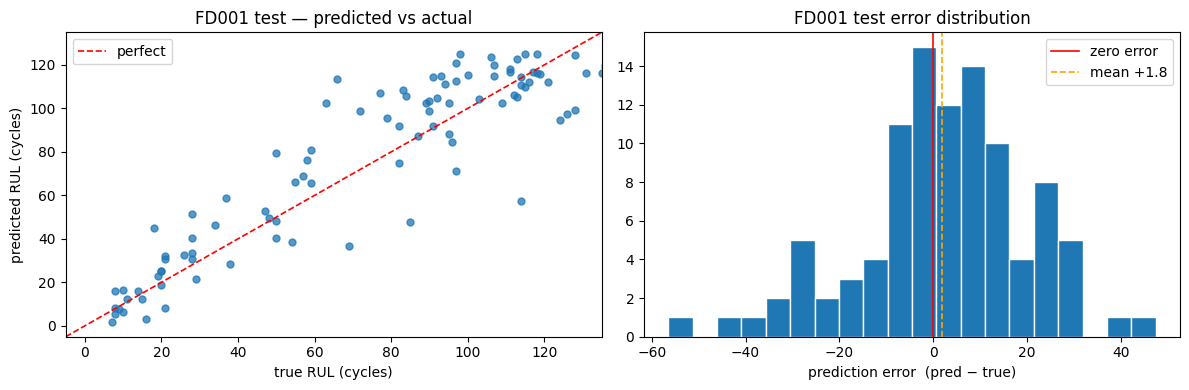

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(y_te1, pred_te1, s=25, alpha=0.75)
lim = [-5, RUL_CAP + 10]
ax.plot(lim, lim, 'r--', lw=1.2, label='perfect')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('true RUL (cycles)')
ax.set_ylabel('predicted RUL (cycles)')
ax.set_title('FD001 test — predicted vs actual')
ax.legend()

errors1 = pred_te1 - y_te1
ax = axes[1]
ax.hist(errors1, bins=20, edgecolor='white')
ax.axvline(0, color='r', lw=1.2, label='zero error')
ax.axvline(errors1.mean(), color='orange', lw=1.2, linestyle='--',
           label=f'mean {errors1.mean():+.1f}')
ax.set_xlabel('prediction error  (pred − true)')
ax.set_title('FD001 test error distribution')
ax.legend()

plt.tight_layout()
plt.show()

## Where does the model fail?

Test RMSE is a single number. I want to understand the *shape* of the failures before
doing anything about them. Two questions: Is the model systematically biased in one
direction? Do the errors concentrate in a particular RUL range?

The answers determine what the next experiment should be — I'm not going to add
complexity speculatively.

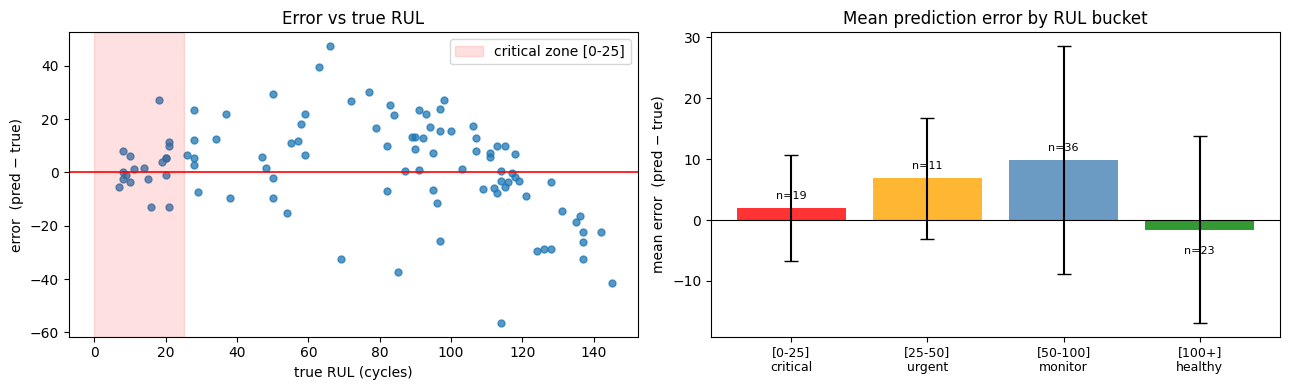

Overall late-prediction rate : 58.0%
Overall mean error           : +1.77 cycles
Critical zone mean error     : +2.02 cycles  (n=19)


In [8]:
errors1 = pred_te1 - y_te1  # positive = late (model thinks engine is healthier than it is)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(y_te1, errors1, s=25, alpha=0.75)
ax.axhline(0, color='r', lw=1.2)
ax.axvspan(0, 25, alpha=0.12, color='red', label='critical zone [0-25]')
ax.set_xlabel('true RUL (cycles)')
ax.set_ylabel('error  (pred − true)')
ax.set_title('Error vs true RUL')
ax.legend()

buckets_err = [(0, 25, '[0-25]\ncritical', 'red'),
               (25, 50, '[25-50]\nurgent',   'orange'),
               (50, 100, '[50-100]\nmonitor', 'steelblue'),
               (100, 126, '[100+]\nhealthy',  'green')]
labels, means, stds, counts = [], [], [], []
for lo, hi, lbl, _ in buckets_err:
    mask = (y_te1 >= lo) & (y_te1 < hi)
    if mask.sum() > 0:
        labels.append(lbl)
        means.append(float(errors1[mask].mean()))
        stds.append(float(errors1[mask].std()))
        counts.append(int(mask.sum()))

colors = [c for lo, hi, lbl, c in buckets_err
          if ((y_te1 >= lo) & (y_te1 < hi)).sum() > 0]
ax = axes[1]
x  = np.arange(len(labels))
ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('mean error  (pred − true)')
ax.set_title('Mean prediction error by RUL bucket')
for i, (m, c) in enumerate(zip(means, counts)):
    ax.text(i, m + (1.5 if m >= 0 else -4), f'n={c}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

crit_mask = y_te1 < 25
print(f'Overall late-prediction rate : {(errors1 > 0).mean() * 100:.1f}%')
print(f'Overall mean error           : {errors1.mean():+.2f} cycles')
print(f'Critical zone mean error     : {errors1[crit_mask].mean():+.2f} cycles'
      f'  (n={int(crit_mask.sum())})')

In [9]:
# Run the same pipeline on FD002, FD003, FD004 and collect test results.
results = {'FD001': test_res1}

for name in ('FD002', 'FD003', 'FD004'):
    print(f'\n-- {name} --')
    tr, te, rul_te = datasets[name]
    engines    = tr['unit'].unique()
    split      = int(len(engines) * 0.8)
    tr_e, va_e = engines[:split], engines[split:]

    feat_tr, stats = add_features(tr[tr['unit'].isin(tr_e)], KEEP, name)
    feat_va, _     = add_features(tr[tr['unit'].isin(va_e)], KEEP, name, stats=stats)
    val_inst       = make_val_instances(feat_va)

    study = tune(feat_tr, val_inst, n_trials=20)
    best  = {**study.best_params, 'n_estimators': 1000, 'tree_method': 'hist',
             'device': XGB_DEV, 'random_state': 42}
    model = XGBoostRUL(params=best)
    model.fit(feat_tr[FEAT_COLS], feat_tr['rul'].values,
              val_inst[FEAT_COLS], val_inst['rul'].values, verbose=False)

    feat_te, _ = add_features(te, KEEP, name, stats=stats)
    res, _, _  = eval_lc(model, feat_te, true_rul=rul_te)
    results[name] = res

    model.save(MODELS / f'xgboost_{name}.pkl')
    joblib.dump(stats, MODELS / f'features_{name}.joblib')

    print(f'  RMSE={res["rmse"]:.2f}  critical={res.get("critical_rmse", float("nan")):.2f}'
          f'  S={res["cmapss_score"]:.0f}  late={res["late_pct"]:.1f}%')


-- FD002 --


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: 18.3291:   0%|          | 0/20 [00:07<?, ?it/s]

Best trial: 0. Best value: 18.3291:   5%|▌         | 1/20 [00:07<02:29,  7.87s/it]

Best trial: 1. Best value: 18.0183:   5%|▌         | 1/20 [00:10<02:29,  7.87s/it]

...

Best trial: 16. Best value: 17.3479:  95%|█████████▌| 19/20 [00:56<00:02,  2.32s/it]

Best trial: 16. Best value: 17.3479:  95%|█████████▌| 19/20 [00:57<00:02,  2.32s/it]

Best trial: 16. Best value: 17.3479: 100%|██████████| 20/20 [00:57<00:00,  2.05s/it]

Best trial: 16. Best value: 17.3479: 100%|██████████| 20/20 [00:57<00:00,  2.89s/it]

  RMSE=27.93  critical=8.64  S=4890  late=50.4%


In [10]:
from IPython.display import display

rows = []
for name, res in results.items():
    def _f(k): return f"{res.get(k, float('nan')):.2f}"
    rows.append({
        'dataset'      : name,
        'RMSE'         : _f('rmse'),
        '[0-25] crit'  : _f('critical_rmse'),
        '[25-50] urg'  : _f('urgent_rmse'),
        '[50-100] mon' : _f('monitor_rmse'),
        '[100+] hlth'  : _f('healthy_rmse'),
        'NASA score'   : f"{res['cmapss_score']:.0f}",
        'late %'       : f"{res['late_pct']:.1f}",
    })

df_results = pd.DataFrame(rows).set_index('dataset')
display(df_results)

,RMSE,[0-25] crit,[25-50] urg,[50-100] mon,[100+] hlth,NASA score,late %
dataset,,,,,,,
FD001,17.78,8.96,12.08,21.14,19.09,596,58.0
FD002,27.83,5.68,10.60,20.83,41.64,12641,44.8
FD003,16.88,4.59,8.44,21.67,16.82,759,54.0
FD004,27.93,8.64,17.71,23.22,37.61,4890,50.4


## Decision log

**Evaluation protocol:** truncation instances for val (every 5th degradation cycle per
engine → 500 instances for FD001); last-cycle-per-engine for test (one prediction at
NASA's defined truncation point). Both measure single-point prediction at a truncation,
so val and test numbers are directly comparable. All-rows RMSE is discarded.

**Model:** XGBoost, 20-trial Optuna search per dataset, objective = val-instance RMSE.
Light tuning was the right call: the val-instance objective gives a well-calibrated
signal across the full RUL range, and 20 trials reliably finds a better-than-default
configuration without overfitting the search budget.

**Baseline numbers (42 features, test set, last-cycle per engine):**

| Dataset | RMSE  | [0–25] crit | NASA score | Late % |
|---------|-------|-------------|------------|--------|
| FD001   | 17.78 | 8.96        | 596        | 58.0 % |
| FD002   | 27.83 | 5.68        | 12 641     | 44.8 % |
| FD003   | 16.88 | 4.59        | 759        | 54.0 % |
| FD004   | 27.93 | 8.64        | 4 890      | 50.4 % |

**EWM experiment — tried and dropped.**
Added a 4th derived feature per sensor (exponentially weighted mean, span=15) on the
hypothesis that recent-cycle weighting would improve critical-zone accuracy near failure.

Results with EWM (56 features, FD001 test):
- Global RMSE: 17.61 (barely changed from 17.78)
- Critical [0–25] RMSE: **9.62 — worse than baseline 8.96**
- NASA score: 616 (slightly worse)
- Late %: 57 % (flat)

EWM was not the bottleneck. It added 14 correlated features that gave the model more
rope to overfit without improving the target bucket. Reverted to 42 features; the
notebook outputs reflect the 42-feature baseline.

**Failure analysis — FD001:**
- 58 % of predictions are late (pred > true)
- Overall mean error: +1.77 cycles
- Critical-zone [0–25] mean error: **+2.02 cycles** (n = 19 engines)
- Critical-zone RMSE (8.96) is the lowest of the four buckets — the model is most
  accurate near failure in absolute terms. The late bias is the problem.

**Future experiment (not yet run): asymmetric loss.**
The critical zone is already the most accurate bucket (RMSE 8.96), and its error is mostly
scatter — the mean error there is only +2.02 cycles. So the open issue near failure isn't
accuracy, it's that 58% of predictions are late, and late predictions are the operationally
dangerous ones. An asymmetric training objective — penalising late predictions more than
early ones — would bias the model toward the safe side.

This is deliberately not implemented. The model is the lean fit/predict/persist wrapper and
has no custom-objective support; adding asymmetric loss means adding a custom objective to
`src/turbofan/models/xgboost_model.py` as a justified change, not a default. It's worth doing
only if the safety trade is judged acceptable: an earlier run showed asymmetric loss can lower
the late-prediction rate while *worsening* the NASA score, because it trades calibrated
accuracy for a safety margin. Treat it as a measured experiment with that trade-off in mind.

If that trade isn't worth it, the health index — a single aggregate degradation score from
the sensor ensemble, the other high-importance feature the lean set dropped — is the next
candidate. Neither should be added speculatively.